<a href="https://colab.research.google.com/github/Ronaa-MX/Stochatic/blob/processes/Sol_Juegos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Escaleras y Serpientes

### Solución Analítica
Se propone una matriz de transición de $20\times20$ al contar con 19 estados únicos, donde consideramos a sólo alguno s estados transitorios. Dado que jugamos con un sólo dado al tirar, los siguientes casillas tendran una probabilidad de avanzar de la casilla con un $P=\frac{1}{6}$. Solucionando con la matriz fundamentarl, tendremos que el número de tiradas promedio para poder llegar a la casilla 20, es:

In [9]:
# Libreŕias a usar
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [2]:
def solve_snakes_ladders():
   # Definimos el tablero (0 a 19 son estados transitorios)
    size = 20
    jumps = {3: 11, 15: 19, 13: 4, 17: 10}

    # Crear una matriz Q de ceros con SymPy para mantener fracciones exactas
    Q = sp.zeros(size, size)

    for i in range(size):
        for die in range(1, 7):
            next_s = i + die

            # Regla: si excede 20, se queda en i
            if next_s > 20:
                final_s = i
            elif next_s == 20:
                # El estado 20 es absorbente, no entra en la matriz Q
                continue
            else:
                # Aplicar serpientes o escaleras
                final_s = jumps.get(next_s, next_s)

            # Si el salto lleva a la meta (20), no se suma a Q
            if final_s < 20:
                Q[i, final_s] += sp.Rational(1, 6)

    # Calcular Matriz Fundamental N = (I - Q)^-1
    I = sp.eye(size)
    N = (I - Q).inv()

    # El tiempo esperado desde la casilla 0 es la suma de la primera fila
    expected_steps = sum(N.row(0))
    return expected_steps
avg_turns = solve_snakes_ladders()
print(f'Jugadas promedio para ganar serpientes y escaleras {avg_turns:.2f}')

Jugadas promedio para ganar serpientes y escaleras 11.60


### Solución por simulación

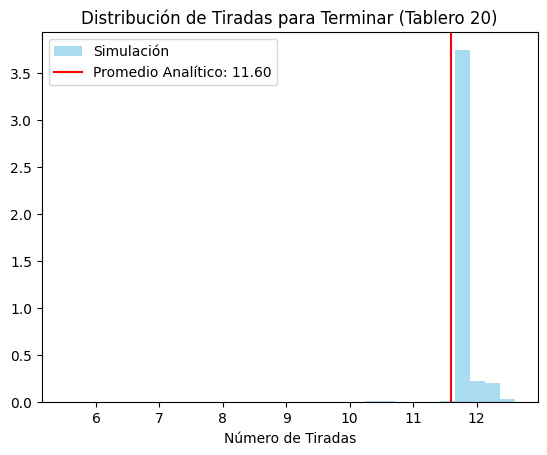

Promedio de tiradas necesarias: 11.6001


In [4]:
# Simulación para histograma
def simulate_game(n=10000):
    jumps = {2: 10, 14: 18, 12: 3, 16: 9}
    history = []
    for _ in range(n):
        pos, turns = 0, 0
        while pos < 20:
            die = np.random.randint(1, 7)
            new_p = pos + die
            if new_p <= 20: pos = jumps.get(new_p, new_p)
            turns += 1
        history.append(turns)
    history_means = np.cumsum(history) / np.arange(1, len(history) + 1)
    return history_means

sim_hist = simulate_game()
plt.hist(sim_hist, bins=30, density=True, alpha=0.7, color='skyblue', label='Simulación')
plt.axvline(avg_turns, color='red', label=f'Promedio Analítico: {avg_turns:.2f}')
plt.title("Distribución de Tiradas para Terminar (Tablero 20)")
plt.xlabel("Número de Tiradas")
plt.legend()
plt.show()

print(f"Promedio de tiradas necesarias: {avg_turns:.4f}")

## Ratón en laberinto
## Solución Analítica

Proponemos para el proceso, una matriz transitoria de $9\times 9$ dado que se tiene 9 casillas, su probabilidad de cada estado se vera dada por el número de casillas adyacentes que tiene para ir el ratón. Nuestras entradas absorbentes serán las que son dond si el ratón inicia ahí, no ocurrira nada, como en la 7 u 8, ya que cada una tiene la comida y la otra un shock. Cómo en el caso de serpientes y escaleras, solucionando el sistema en base a la matriz fundamental, obtendremos que al probabilidad de terminar en el queso, empezando en la casiila 0, es:

In [5]:
# --- SOLUCIÓN ANALÍTICA CON SYMPY ---
# Definir estados transitorios: 0, 1, 2, 3, 4, 5, 6
Q = sp.Matrix([
    [0, 1/2, 1/2, 0, 0, 0, 0],       # 0
    [1/3, 0, 0, 1/3, 0, 0, 0],       # 1
    [1/3, 0, 0, 1/3, 0, 0, 0],       # 2
    [0, 1/4, 1/4, 0, 1/4, 1/4, 0],   # 3
    [0, 0, 0, 1/3, 0, 0, 1/3],       # 4
    [0, 0, 0, 1/3, 0, 0, 1/3],       # 5
    [0, 0, 0, 0, 1/2, 1/2, 0]        # 6
])

# Matriz R (transiciones a 7 y 8)
R = sp.Matrix([
    [0,0],# 0
    [1/3, 0],   # 1 -> 7
    [0, 1/3],   # 2 -> 8
    [0,0],# 3
    [1/3, 0],   # 4 -> 7
    [0, 1/3],  # 5 -> 8
    [0,0]     # 6
    ])

I = sp.eye(7)
N = (I - Q).inv()
B = N * R
prob_comida_desde_0 = B

print(f"Probabilidad analítica (Comida): {prob_comida_desde_0[0,0]:.2f}")

Probabilidad analítica (Comida): 0.50


### Solución por simulación

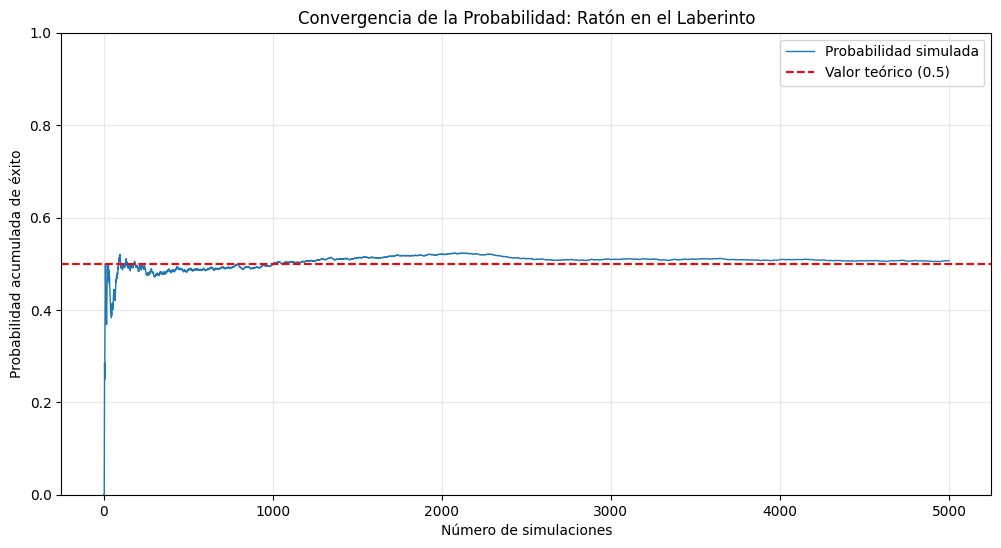

In [12]:
def sim_laberinto(n_simulaciones=5000):
    # Conexiones basadas en la estructura del laberinto
    adyacencia = {
        0: [1, 2],
        1: [0,3,7],
        2: [0,3,8],
        3: [1, 2, 4, 5],
        4: [3,6,7],
        5: [3,6,8],
        6: [4,5]
    }

    resultados_exito = [] # Guardará 1 si llega a 7, 0 si llega a 8

    for _ in range(n_simulaciones):
        actual = 0 # Inicio en casilla 0
        while actual in adyacencia:
            opciones = adyacencia[actual]
            # Elección equiprobable de salidas [1]
            actual = int(np.random.choice(opciones))

        resultados_exito.append(1 if actual == 7 else 0)

    # Calcular la probabilidad acumulada (convergencia)
    probabilidades_acumuladas = np.cumsum(resultados_exito) / np.arange(1, n_simulaciones + 1)

    # Graficar la convergencia
    plt.figure(figsize=(12, 6))
    plt.plot(probabilidades_acumuladas, label='Probabilidad simulada', color='#1f77b4', linewidth=1)
    plt.axhline(y=0.5, color='red', linestyle='--', label='Valor teórico (0.5)')

    plt.title("Convergencia de la Probabilidad: Ratón en el Laberinto")
    plt.xlabel("Número de simulaciones")
    plt.ylabel("Probabilidad acumulada de éxito")
    plt.ylim(0, 1) # Rango de probabilidad de 0 a 1
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Ejecutar visualización
sim_laberinto()